In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [4]:
accuracy_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    score = knn.score(X_test, y_test)

    accuracy_scores.append(score)

    print(f"K = {k}, Accuracy = {score:.4f}")

K = 1, Accuracy = 0.9778
K = 2, Accuracy = 0.9806
K = 3, Accuracy = 0.9833
K = 4, Accuracy = 0.9806
K = 5, Accuracy = 0.9861
K = 6, Accuracy = 0.9889
K = 7, Accuracy = 0.9889
K = 8, Accuracy = 0.9861
K = 9, Accuracy = 0.9806
K = 10, Accuracy = 0.9833
K = 11, Accuracy = 0.9833
K = 12, Accuracy = 0.9778
K = 13, Accuracy = 0.9778
K = 14, Accuracy = 0.9806
K = 15, Accuracy = 0.9778
K = 16, Accuracy = 0.9806
K = 17, Accuracy = 0.9833
K = 18, Accuracy = 0.9806
K = 19, Accuracy = 0.9750
K = 20, Accuracy = 0.9778


In [5]:
best_accuracy = max(accuracy_scores)

best_k = accuracy_scores.index(best_accuracy) + 1

print("Best K =", best_k)
print("Best Accuracy =", best_accuracy)

Best K = 6
Best Accuracy = 0.9888888888888889


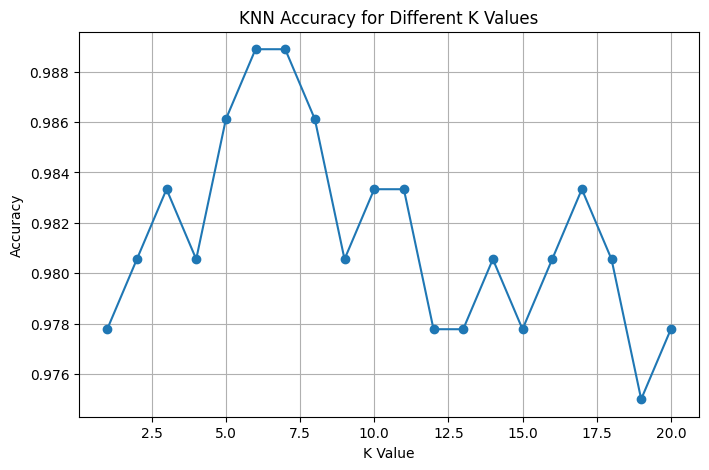

In [6]:
plt.figure(figsize=(8,5))

plt.plot(range(1,21), accuracy_scores, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.grid(True)

plt.show()

In [7]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

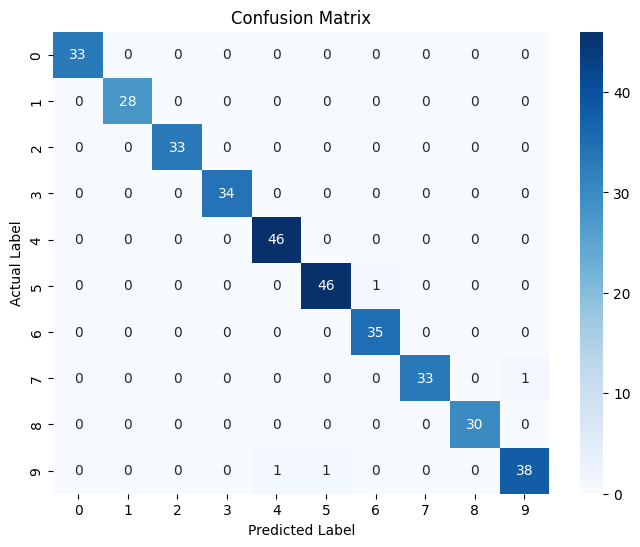

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

